# 🚀 NEXTGEN QA - Failure Analysis ML Pipeline



### 📋 Pipeline Flow:
1. **Understand Problem** → Define the root cause classification task.
2. **Clean Data** → Load and filter the synthetic dataset.
3. **Preprocess** → TF-IDF vectorization, Categorical Encoding, and SMOTE.
4. **Split** → 80/20 Train/Test separation.
5. **Train Random Forest** → Standard tree-based classifier.
6. **Train Gradient Boosting** → Boosting-based approach.
7. **Predict** → Generate inferences on unseen data.
8. **Evaluate** → Detailed metrics and confusion matrices.
9. **Compare** → Visual model performance comparison.
10. **Tune Model** → Hyperparameter optimization overview.
11. **Save Final Model** → Export artifacts for production.
12. **Deploy (Optional)** → Integration with API services.

## 🛠️ Environment Setup

In [1]:
import os
import sys
import json
import shutil
import warnings
import numpy as np
import pandas as pd
import joblib
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 🔍 Step 1: Understand Problem

The goal is to automatically classify test failures into one of 6 root causes based on error messages, stack traces, and test execution metadata. 

**Root Causes:**
- `application_defect`
- `environment_failure`
- `locator_issue`
- `network_api_error`
- `synchronization_issue`
- `test_data_issue`

## 🧹 Step 2: Clean Data

We load the dataset and perform basic cleaning: removing nulls, normalizing strings, and ensuring class balance for the research phase.

In [2]:
# Determine paths
BASE_DIR = os.path.dirname(os.getcwd())
DATASET_PATH = os.path.join(BASE_DIR, "research", "data", "final_training_dataset.csv")
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = os.path.join(os.getcwd(), "data", "final_training_dataset.csv")

print(f"📂 Loading: {DATASET_PATH}")
df = pd.read_csv(DATASET_PATH, low_memory=False)

# Cleaning
df = df.dropna(subset=["root_cause"])
df["root_cause"] = df["root_cause"].str.strip().str.lower()

VALID_CLASSES = [
    "locator_issue", "synchronization_issue", "test_data_issue",
    "environment_failure", "network_api_error", "application_defect"
]
df = df[df["root_cause"].isin(VALID_CLASSES)].reset_index(drop=True)

print(f"📊 Total Records: {len(df):,}")

📂 Loading: e:\SLIIT\4th_Year\1st Semester\Research\failure-analysis-self-healing\research\data\final_training_dataset.csv
📊 Total Records: 45,850


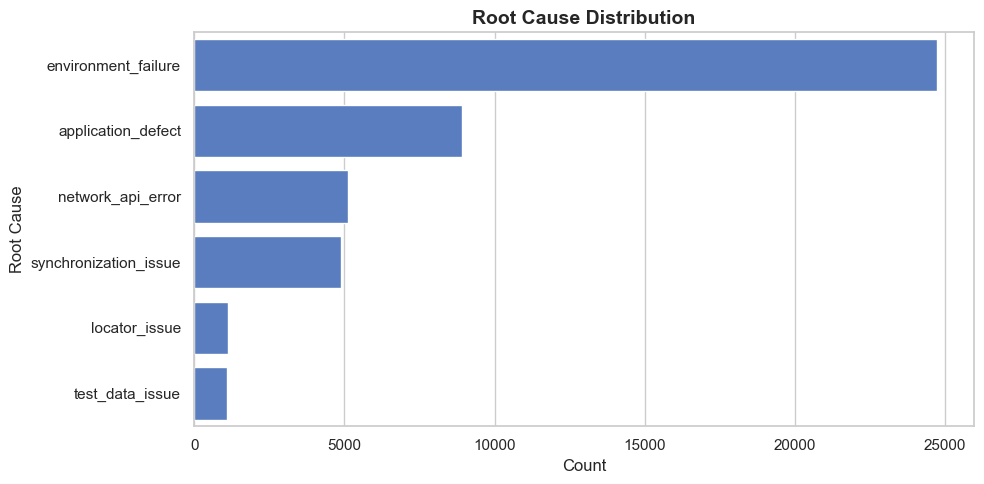

In [3]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y="root_cause", order=df["root_cause"].value_counts().index)
plt.title("Root Cause Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Root Cause")
plt.tight_layout()
plt.show()

## 🧪 Step 3: Preprocess

We convert raw text into numerical features using **TF-IDF** and encode categorical fields. We also apply **SMOTE** to handle class imbalance.

In [4]:
# Fill NAs
df["error_message"] = df["error_message"].fillna("").astype(str)
df["stack_trace"] = df["stack_trace"].fillna("").astype(str)
df["failure_stage"] = df["failure_stage"].fillna("unknown")
df["severity"] = df["severity"].fillna("MEDIUM")
df["failure_type"] = df["failure_type"].fillna("unknown")

print("✨ Extracting TF-IDF features...")
vec_msg = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_msg = vec_msg.fit_transform(df["error_message"])

vec_trace = TfidfVectorizer(max_features=200, ngram_range=(1, 2), sublinear_tf=True)
X_trace = vec_trace.fit_transform(df["stack_trace"])

print("✨ Encoding categorical metadata...")
cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_cat = cat_encoder.fit_transform(df[["failure_stage", "severity", "failure_type"]])

print("✨ Cleaning numeric features...")
numeric_cols = ["retry_count", "test_duration_sec", "cpu_usage_pct", "memory_usage_mb", "is_flaky_test"]

# Explicitly map boolean strings to numbers to avoid NaN errors
if "is_flaky_test" in df.columns:
    df["is_flaky_test"] = df["is_flaky_test"].map({True: 1, False: 0, "True": 1, "False": 0, "1": 1, "0": 0}).fillna(0)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

X_num = df[numeric_cols].values.astype(np.float64)

X = hstack([
    X_msg, 
    X_trace, 
    csr_matrix(X_cat.astype(np.float64)), 
    csr_matrix(X_num)
])

le = LabelEncoder()
y = le.fit_transform(df["root_cause"])

print(f"✅ Feature Matrix Constructed: {X.shape[0]} samples x {X.shape[1]} features.")

✨ Extracting TF-IDF features...
✨ Encoding categorical metadata...
✨ Cleaning numeric features...
✅ Feature Matrix Constructed: 45850 samples x 708 features.


## ✂️ Step 4: Split (80/20)

We split the data into training and validation sets, and apply SMOTE to the training set only.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# Handle Class Imbalance
counts = Counter(y_train)
if min(counts.values()) < 500:
    print("⚖️ Applying SMOTE...")
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"New training set size: {X_train.shape[0]}")

Training set: 36680 samples
Testing set:  9170 samples


## 🌲 Step 5: Train Random Forest

Training a robust Forest of trees to capture feature interactions.

In [6]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"🌲 RF Accuracy: {rf_acc:.2%}")

Training Random Forest...
🌲 RF Accuracy: 72.05%


## 📈 Step 6: Train Gradient Boosting

Using an additive model to correct errors from previous steps.

In [7]:
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))
print(f"📈 GB Accuracy: {gb_acc:.2%}")

Training Gradient Boosting...
📈 GB Accuracy: 89.76%


## 🔮 Step 7 & 8: Predict & Evaluate

Selecting the best model and generating detailed classification reports.

🏆 Best Model: GradientBoosting (89.76%)

                       precision    recall  f1-score   support

   application_defect       0.90      0.91      0.91      1785
  environment_failure       0.90      0.99      0.94      4944
        locator_issue       0.77      0.15      0.25       225
    network_api_error       0.90      0.84      0.87      1022
synchronization_issue       0.90      0.84      0.87       977
      test_data_issue       0.71      0.06      0.10       217

             accuracy                           0.90      9170
            macro avg       0.84      0.63      0.66      9170
         weighted avg       0.89      0.90      0.88      9170



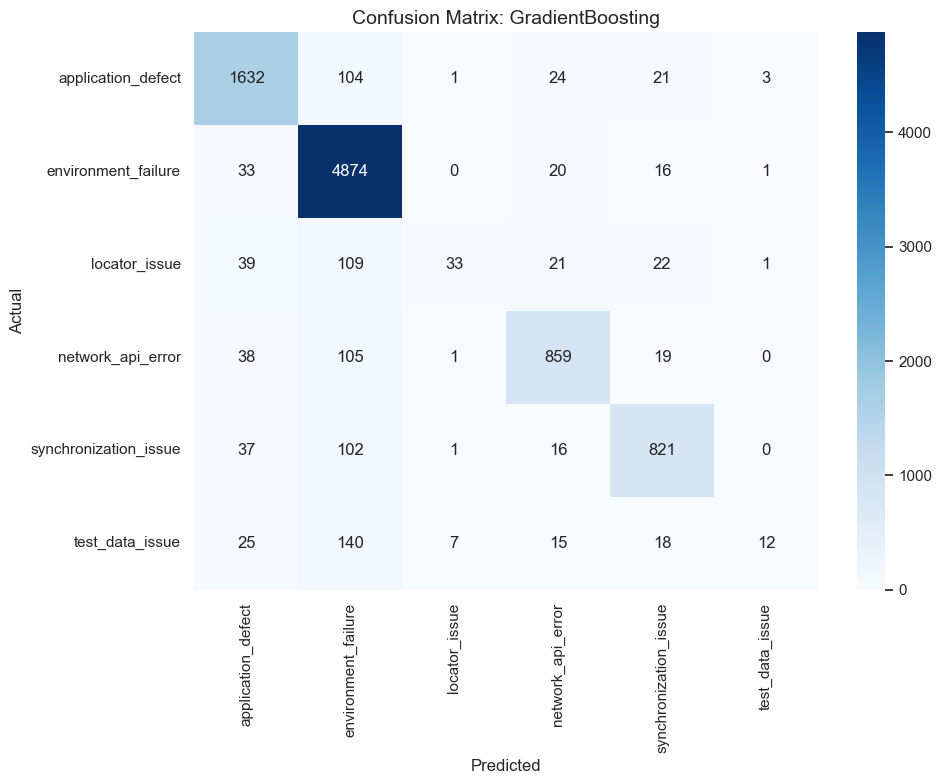

In [8]:
best_name, best_model, best_acc = ("RandomForest", rf, rf_acc) if rf_acc > gb_acc else ("GradientBoosting", gb, gb_acc)
print(f"🏆 Best Model: {best_name} ({best_acc:.2%})\n")

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {best_name}", fontsize=14)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 📊 Step 9: Compare Models

A visual comparison of accuracy between the two algorithms.

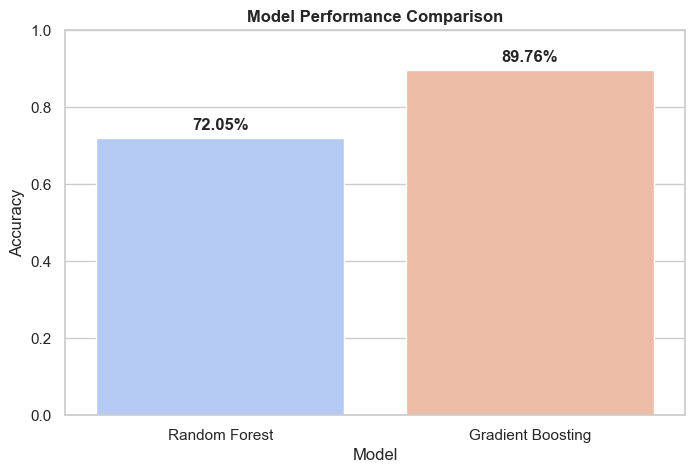

In [9]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Accuracy": [rf_acc, gb_acc]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette="coolwarm")
plt.ylim(0, 1.0)
plt.title("Model Performance Comparison", fontweight="bold")
for i, val in enumerate(comparison_df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2%}", ha="center", fontweight="bold")
plt.show()

## ⚙️ Step 10: Tune Model

In a production setting, we use `GridSearchCV` to find optimal hyperparameters. 

**Example Search Space:**
- `n_estimators`: [50, 100, 200]
- `max_depth`: [None, 10, 20]
- `min_samples_split`: [2, 5]

In [10]:
print("💡 Pro-tip: Use GridSearchCV for systematic tuning.")
# tuned_rf = GridSearchCV(rf, param_grid={'n_estimators': [50, 100], 'max_depth': [10, 20]}, cv=3)
# tuned_rf.fit(X_train, y_train)

💡 Pro-tip: Use GridSearchCV for systematic tuning.


## 💾 Step 11: Save Final Model

We export all artifacts required for the inference engine.

In [11]:
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

artifacts = {
    "classifier.pkl": best_model,
    "vectorizer_msg.pkl": vec_msg,
    "vectorizer_trace.pkl": vec_trace,
    "cat_encoder.pkl": cat_encoder,
    "label_encoder.pkl": le
}

print("💾 Saving artifacts to root /models...")
for fname, obj in artifacts.items():
    joblib.dump(obj, os.path.join(MODELS_DIR, fname), compress=3)

print("✅ All artifacts saved. Model is ready for deployment!")

💾 Saving artifacts to root /models...
✅ All artifacts saved. Model is ready for deployment!


## 🌐 Step 12: Deploy (Optional)

The saved artifacts are consumed by the **Backend API** in `backend/app/core/ml_classifier.py`. 

**Deployment Steps:**
1. Start Backend: `uvicorn app.main:app` 
2. Submit test failures to `/api/analyze` endpoint.
3. View results on the **NEXTGEN QA Dashboard**.